# Survival prediction with cancer WSIs

In this tutorial, you will be introduced to building survival prediction models using both machine learning and deep learning approaches with WSIs.

We will use a subset of WSIs from **TCGA-READ** for illustration purposes only. The provided code and analyses are intended solely as a demonstration of workflow and usage. The results shown here are not validated and should not be used for drawing biological or clinical conclusions.

In [1]:
from huggingface_hub import hf_hub_download

metadata = hf_hub_download(
    "rendeirolab/lazyslide-data",
    "TCGA_READ_survival.csv",
    repo_type="dataset",
    local_dir=".",
)

In [2]:
import pandas as pd

metadata = pd.read_csv(metadata)
metadata.head(5)

,PATIENT_ID,AGE,AJCC_STAGING_EDITION,BIOPSY_SITE,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_DEATH,DISEASE_TYPE,ETHNICITY,ICD_10,...,SEX,VITAL_STATUS,YEAR_OF_DIAGNOSIS,OS_STATUS,OS_MONTHS,PROJECT_ID,PROJECT_NAME,PROJECT_STATE,FILE_ID,FILE_NAME
0,TCGA-AG-3601,68.0,6th,Rectum,0.0,-24837.0,NaN,Rectal Adenocarcinoma,NaN,C19,...,Male,Alive,2007.0,0:LIVING,0.000000,TCGA-READ,Rectal Adenocarcinoma,released,d76f3d2c-f30d-4592-a51d-620e17419222,TCGA-AG-3601-01Z-00-DX1.30ac783e-ba70-49ef-8be...
1,TCGA-AF-6136,72.0,7th,Rectum,232.0,-26490.0,NaN,Rectal Adenocarcinoma,NOT HISPANIC OR LATINO,C19,...,Female,Alive,2011.0,0:LIVING,24.342970,TCGA-READ,Rectal Adenocarcinoma,released,ec1f9ff4-f634-42fb-9c64-dee4950df4df,TCGA-AF-6136-01Z-00-DX1.a0e22964-b7b4-43ba-bfa...
2,TCGA-AH-6549,66.0,7th,Rectum,6.0,-24337.0,NaN,Rectal Adenocarcinoma,NaN,C20,...,Male,Alive,2010.0,0:LIVING,17.477004,TCGA-READ,Rectal Adenocarcinoma,released,1f07b827-255a-4d32-9eea-f2daff7bd937,TCGA-AH-6549-01Z-00-DX1.38ea40f7-4ebf-49cc-801...
3,TCGA-AG-A01Y,49.0,5th,Rectum,0.0,-18112.0,NaN,Rectal Adenocarcinoma,NaN,C20,...,Female,Alive,2004.0,0:LIVING,0.000000,TCGA-READ,Rectal Adenocarcinoma,released,b7c07212-1bc0-48b3-8b69-6adffa0fb08f,TCGA-AG-A01Y-01Z-00-DX1.3F49940B-3758-419B-89C...
4,TCGA-AG-3883,69.0,6th,Rectum,31.0,-25415.0,NaN,Rectal Adenocarcinoma,NaN,C20,...,Male,Alive,2008.0,0:LIVING,1.018397,TCGA-READ,Rectal Adenocarcinoma,released,2d8f32f9-bb04-46cd-8d63-91b591e9b8b3,TCGA-AG-3883-01Z-00-DX1.2a21ffb1-8a60-4424-b74...


Let's first visualize the data distribution of a few variables.

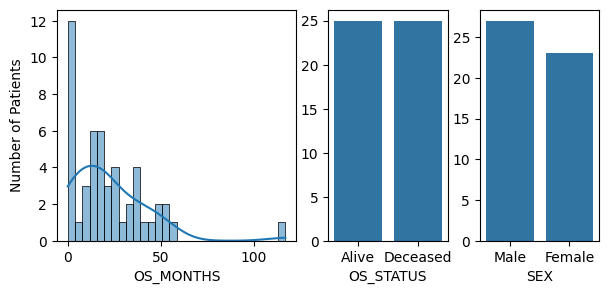

In [3]:
# Plot the distribution of overall survival time
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(7, 3), width_ratios=[2, 1, 1])
sns.histplot(data=metadata["OS_MONTHS"], bins=30, kde=True, ax=axs[0])
axs[0].set(ylabel="Number of Patients")

# Plot the distribution of OS_STATUS
sns.countplot(x="OS_STATUS", data=metadata, ax=axs[1])
axs[1].set(ylabel="")
axs[1].set_xticks(ticks=[0, 1], labels=["Alive", "Deceased"])

# Plot the distribution of SEX
sns.countplot(x="SEX", data=metadata, ax=axs[2])
axs[2].set(ylabel="")
plt.show()

To get all svs files, run the following code:
```python
slides = snapshot_download(
    "rendeirolab/lazyslide-data",
    repo_type="dataset",
    local_dir="tcga_read",
    allow_patterns=["tcga_read/*.svs"],
)
```

Now let's run feature extration on these slides, you can parallel it however you want depends on your infrastructure setup, 
here is a demo code to parallel across GPU nodes with SLURM.

```python
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

def wsi_feature_extraction(slide):

    from wsidata import open_wsi
    import lazyslide as zs

    wsi = open_wsi(s, attach_thumbnail=False)
    zs.pp.find_tissues(wsi)
    zs.pp.tile_tissues(wsi, 448, mpp=0.5, background_fraction=0.5)

    zs.tl.feature_extraction(wsi, "titan", pbar=False)
    zs.tl.feature_aggregation(wsi, "titan", encoder="titan")
    wsi.write()

cluster = SLURMCluster(
    queue="gpu",
    cores=8,
    processes=1,
    memory="10 GB",
    job_extra_directives=[
        "-q gpu",
        "--gres=gpu:h100pcie:1",
        "--time=1:00:00",
    ],
    worker_extra_args=["--resources GPU=1"],
    log_directory="./dask-logs",
)

client = Client(cluster)
cluster.scale(10)  # Get 10 workers, each with one H100 to run

futures = [
    client.submit(wsi_feature_extraction, f"slides/{slide}", resources={"GPU": 1})
    for slide in matadata["FILE_NAME"]
]
```

When you finished with the processing, you can aggregate the slide features with

```python
from wsidata import agg_wsi

matadata["slide_path"] = [f"tcga_read/{s}" for s in matadata["FILE_NAME"]]
adata = agg_wsi(matadata, wsi_col="slide_path", feature_key="titan")
```

We have prepared a pre-computed features matrix if you don't want to run the feature extration.

In [4]:
import anndata as ad

titan_features = hf_hub_download(
    "rendeirolab/lazyslide-data",
    "TCGA_READ_subset_TITAN.h5ad",
    repo_type="dataset",
    local_dir=".",
)

adata = ad.read_h5ad(titan_features)
adata.obs["status"] = (
    adata.obs["OS_STATUS"].map({"0:LIVING": 0, "1:DECEASED": 1}).astype(bool)
)
adata

AnnData object with n_obs × n_vars = 50 × 768
    obs: 'PATIENT_ID', 'AGE', 'AJCC_STAGING_EDITION', 'BIOPSY_SITE', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_DEATH', 'DISEASE_TYPE', 'ETHNICITY', 'ICD_10', 'MORPHOLOGY', 'OTHER_PATIENT_ID', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_STAGE', 'PATH_T_STAGE', 'PRIMARY_DIAGNOSIS', 'PRIMARY_SITE_PATIENT', 'PRIOR_MALIGNANCY', 'PRIOR_TREATMENT', 'RACE', 'SEX', 'VITAL_STATUS', 'YEAR_OF_DIAGNOSIS', 'OS_STATUS', 'OS_MONTHS', 'PROJECT_ID', 'PROJECT_NAME', 'PROJECT_STATE', 'FILE_ID', 'FILE_NAME', 'slide_path', 'status'

Let's visualize the morphological features of the dataset in PCA space. 

Additonally, we can also run unsupervised clustering to cluster the data based on morphological features.

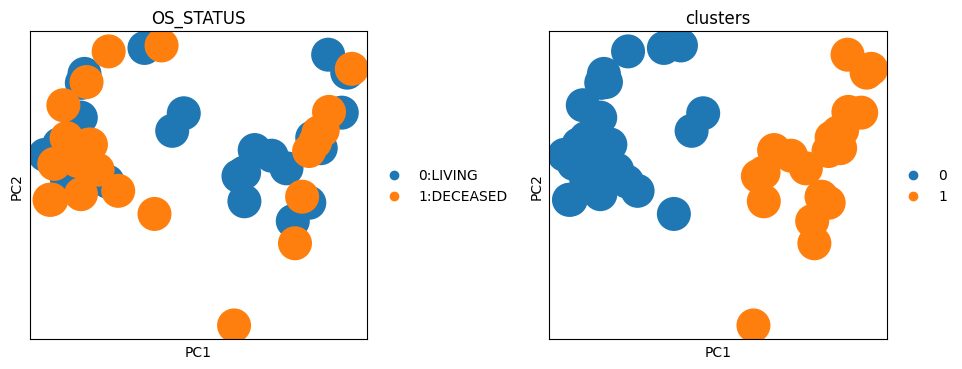

In [5]:
import scanpy as sc

sc.pp.scale(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", key_added="clusters")

sc.pl.pca(adata, color=["OS_STATUS", "clusters"], wspace=0.4)

## Kaplan meier estimator

Kaplan-Meier (KM) estimator is a widely used non-parametric method for estimating survival probabilities over time, especially when dealing with censored data. KM plots are commonly featured in biomedical publications to visualize survival curves.

In practical research scenarios, KM analysis helps compare survival outcomes between different patient groups, such as treated vs. untreated cohorts. In this tutorial, we use KM estimator to investigate whether the survival is different among the 'clusters' we derived unsupervisely. This approach provides an intuitive way to assess the impact of clinical or biological factors on patient prognosis.

To compare the survival difference between two groups, a log-rank test is usually applied.

Log-rank test of survival difference with p-value: 0.12


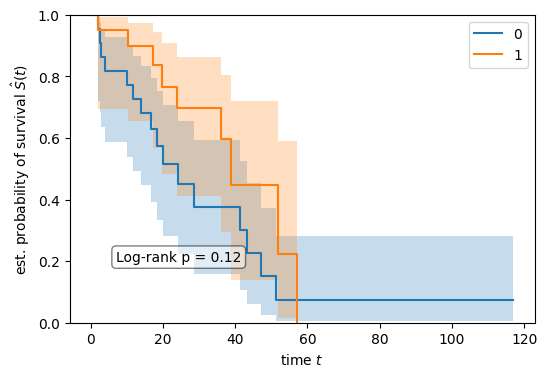

In [6]:
import matplotlib.pyplot as plt

from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival

with plt.rc_context({"figure.figsize": (6, 4)}):
    for group in adata.obs["clusters"].unique():
        mask = adata.obs["clusters"] == group
        time, survival_prob, conf_int = kaplan_meier_estimator(
            adata.obs["status"][mask], adata.obs["OS_MONTHS"][mask], conf_type="log-log"
        )
        plt.step(time, survival_prob, where="post", label=f"{group}")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
    plt.ylim(0, 1)
    plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
    plt.xlabel("time $t$")
    plt.legend()

    _, pvalue = compare_survival(
        adata.obs[["status", "OS_MONTHS"]].to_records(index=False),
        adata.obs["clusters"],
    )
    plt.text(
        0.1,
        0.2,
        f"Log-rank p = {pvalue:.2f}",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
    )

print(f"Log-rank test of survival difference with p-value: {pvalue:.2f}")

No statistically significant survival difference was observed between cluster 0 and cluster 1 in this subset (log-rank p = 0.12). 

**Disclaimer:** The analysis presented here is based on a limited subset of TCGA-READ cases and is intended solely for demonstration purposes. These results have not been clinically validated and should not be interpreted as evidence for biological or clinical conclusions.

## Machine learning model
Let's start with a machine learning based model. We used the model from [scikit-survival](https://scikit-survival.readthedocs.io/en/stable/).

The metric we use to evaluate the model is called **Concordance Index (cindex)**.

The concordance index (cindex) is a measure of how well a survival model predicts the order of events. It quantifies the agreement between the predicted risk scores and the actual observed survival times, with a value of 1.0 indicating perfect prediction and 0.5 indicating random chance. A reasonable model performance should have cindex > 0.7.

In [7]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    adata.X,
    adata.obs[["status", "OS_MONTHS"]].to_records(index=False),
    test_size=0.2,
    stratify=adata.obs["status"],
    random_state=10,
)

model = CoxnetSurvivalAnalysis(
    l1_ratio=0.9, alpha_min_ratio=0.01, n_alphas=100, fit_baseline_model=True
)
model.fit(X_train, y_train)
s = model.score(X_test, y_test)
print("cindex:", model.score(X_test, y_test))

cindex: 0.6428571428571429


## Neural network

If you have a lot of data, you can train a neural network to predict the hazard ratio.

Let's defined a simple models with the input of slide features and output of hazard ratio.

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# Define a model
class CoxMLP(nn.Module):
    def __init__(self, in_features, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)  # single risk score

        # Xavier initialization for reproducible weight initialization
        self._init_weights()

    def _init_weights(self):
        """Initialize weights using Xavier initialization"""
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)
        nn.init.xavier_uniform_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)  # risk score, no activation

In [10]:
# Set seeds for reproducibility
torch.manual_seed(0)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

In [11]:
X_train, X_test, E_train, E_test, T_train, T_test = train_test_split(
    adata.X,
    adata.obs["status"].to_numpy(),
    adata.obs["OS_MONTHS"].to_numpy(),
    test_size=0.2,
    stratify=adata.obs["status"],
    random_state=10,
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
E_train = torch.tensor(E_train)
E_test = torch.tensor(E_test)
T_train = torch.tensor(T_train, dtype=torch.float32)
T_test = torch.tensor(T_test, dtype=torch.float32)

Here we use the [torchsurv](https://github.com/Novartis/torchsurv) package for loss function and cindex calculation.

Here we only use a simple training loop for showcase.

In [12]:
from torchsurv.loss import cox
from torchsurv.metrics.cindex import ConcordanceIndex

# The titan features size is 768
model = CoxMLP(768)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Trained for 10 epochs
model.train()
for epoch in range(10):
    optimizer.zero_grad()  # Clear gradients
    estimate = model(X_train)
    loss = cox.neg_partial_log_likelihood(estimate, E_train, T_train)
    loss.backward()
    optimizer.step()  # Update parameters

# Evaluation
with torch.no_grad():
    model.eval()
    log_hz = model(X_test)
    cindex = ConcordanceIndex()
    result = cindex(log_hz, E_test, T_test)
    print(f"C-index: {result:.4f}")

C-index: 0.8571
